# Exercise 1

In [1]:
def generate_stripe_image(size, stripe_nr, vertical = True):
  img=np.zeros((size,size,1),dtype="uint8")
  for i in range(0,stripe_nr):
    x,y = np.random.randint(0,size,2)
    l  = np.random.randint(y,size,1).item()
    if (vertical):
      img[y:l,x,0]=255
    else:
      img[x,y:l,0]=255
  return img  

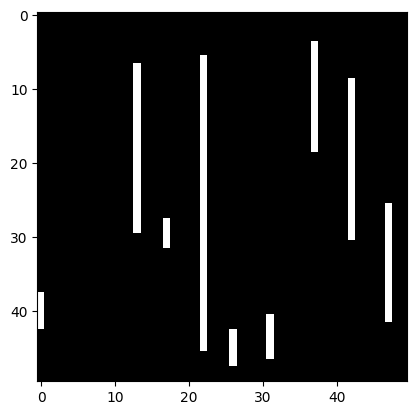

In [2]:
import matplotlib.pyplot as plt
import numpy as np

img=generate_stripe_image(50,10, vertical=True)
plt.imshow(img[:,:,0],cmap='gray')


In [ ]:
# 1.1 

X_train_list = []
for i in range(500):
    X_train_list.append(generate_stripe_image(50, 10, vertical=True))
for i in range(500):
    X_train_list.append(generate_stripe_image(50, 10, vertical=False))
X_train = np.array(X_train_list)

X_val_list = []
for i in range(500):
    X_val_list.append(generate_stripe_image(50, 10, vertical=True))
for i in range(500):
    X_val_list.append(generate_stripe_image(50, 10, vertical=False))
X_val = np.array(X_val_list)

X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (1000, 50, 50, 1)
X_val shape: (1000, 50, 50, 1)


In [4]:
# 1.2 Create labels and convert to one-hot encoding
from tensorflow.keras.utils import to_categorical

# 0 = vertical (first 500), 1 = horizontal (last 500)
Y_train = np.array([0]*500 + [1]*500)
Y_val = np.array([0]*500 + [1]*500)

# Convert to one-hot
Y_train = to_categorical(Y_train, 2)
Y_val = to_categorical(Y_val, 2)

print("Y_train shape:", Y_train.shape)
print("Y_val shape:", Y_val.shape)
print("Example (vertical):", Y_train[0], "Example (horizontal):", Y_train[500])

Y_train shape: (1000, 2)
Y_val shape: (1000, 2)
Example (vertical): [1. 0.] Example (horizontal): [0. 1.]


In [6]:
# 1.3 Build CNN model
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(1, (5, 5), activation='linear', input_shape=(50, 50, 1)),
    layers.MaxPooling2D(pool_size=(46, 46)),
    layers.Flatten(),
    layers.Dense(2, activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 46, 46, 1)         26        
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 1, 1, 1)           0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 1)                 0         
                                                                 
 dense_1 (Dense)             (None, 2)                 4         
                                                                 
Total params: 30 (120.00 Byte)
Trainable params: 30 (120.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [13]:
# 1.4 Train the model
history = model.fit(X_train, Y_train,
                    validation_data=(X_val, Y_val),
                    batch_size=64,
                    epochs=50,
                    verbose=1,
                    shuffle=True)

Epoch 1/50
16/16 [==============================] - 0s 22ms/step - loss: 0.0176 - accuracy: 1.0000 - val_loss: 0.0169 - val_accuracy: 1.0000
Epoch 2/50
16/16 [==============================] - 0s 15ms/step - loss: 0.0171 - accuracy: 1.0000 - val_loss: 0.0165 - val_accuracy: 1.0000
Epoch 3/50
16/16 [==============================] - 0s 15ms/step - loss: 0.0168 - accuracy: 1.0000 - val_loss: 0.0161 - val_accuracy: 1.0000
Epoch 4/50
16/16 [==============================] - 0s 16ms/step - loss: 0.0164 - accuracy: 1.0000 - val_loss: 0.0158 - val_accuracy: 1.0000
Epoch 5/50
16/16 [==============================] - 0s 15ms/step - loss: 0.0160 - accuracy: 1.0000 - val_loss: 0.0154 - val_accuracy: 1.0000
Epoch 6/50
16/16 [==============================] - 0s 19ms/step - loss: 0.0157 - accuracy: 1.0000 - val_loss: 0.0151 - val_accuracy: 1.0000
Epoch 7/50
16/16 [==============================] - 0s 18ms/step - loss: 0.0153 - accuracy: 1.0000 - val_loss: 0.0147 - val_accuracy: 1.0000
Epoch 8/50
16

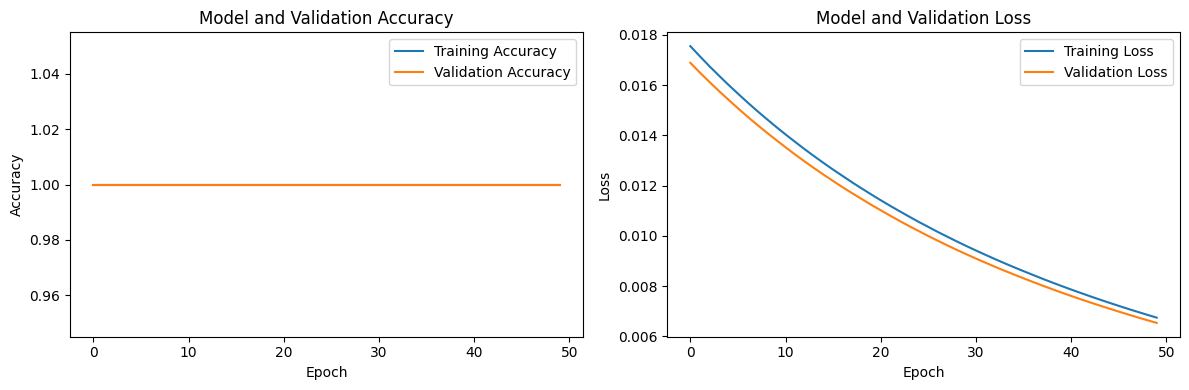

In [14]:
# 1.4 Plot accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model and Validation Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model and Validation Loss')
ax2.legend()

plt.tight_layout()
plt.show()

Kernel shape: (5, 5, 1, 1)


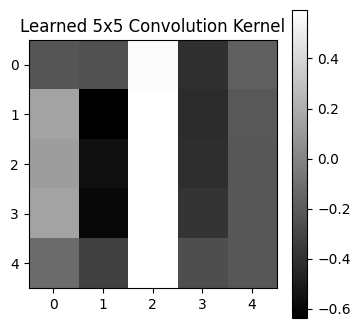

In [9]:
# 1.5 Plot the learned kernel
mykernel = model.get_weights()[0]
print("Kernel shape:", mykernel.shape)

plt.figure(figsize=(4, 4))
plt.imshow(mykernel[:, :, 0, 0], cmap='gray')
plt.title('Learned 5x5 Convolution Kernel')
plt.colorbar()
plt.show()

**1.5 Comment:** The learned kernel shows a pattern where the values vary across columns but remain relatively constant across rows (or vice versa). This is reasonable because a kernel that detects vertical vs horizontal stripes needs to respond differently to edges in one direction compared to the other. When convolved with vertical stripes, the kernel produces a different activation than when convolved with horizontal stripes, allowing the network to distinguish between the two classes after max pooling.

In [15]:
# 1.6 Experiment 1: ReLU activation instead of linear
from tensorflow.keras import layers, models

model_relu = models.Sequential([
    layers.Conv2D(1, (5, 5), activation='relu', input_shape=(50, 50, 1)),
    layers.MaxPooling2D(pool_size=(46, 46)),
    layers.Flatten(),
    layers.Dense(2, activation='softmax')
])
model_relu.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_relu = model_relu.fit(X_train, Y_train, validation_data=(X_val, Y_val),
                              batch_size=64, epochs=50, verbose=0, shuffle=True)

# Experiment 2: Average pooling instead of max pooling
model_avg = models.Sequential([
    layers.Conv2D(1, (5, 5), activation='linear', input_shape=(50, 50, 1)),
    layers.AveragePooling2D(pool_size=(46, 46)),
    layers.Flatten(),
    layers.Dense(2, activation='softmax')
])
model_avg.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_avg = model_avg.fit(X_train, Y_train, validation_data=(X_val, Y_val),
                            batch_size=64, epochs=50, verbose=0, shuffle=True)

# Experiment 3: Different kernel size (3x3)
model_k3 = models.Sequential([
    layers.Conv2D(1, (3, 3), activation='linear', input_shape=(50, 50, 1)),
    layers.MaxPooling2D(pool_size=(48, 48)),
    layers.Flatten(),
    layers.Dense(2, activation='softmax')
])
model_k3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_k3 = model_k3.fit(X_train, Y_train, validation_data=(X_val, Y_val),
                           batch_size=64, epochs=50, verbose=0, shuffle=True)

print("ReLU activation - Final val accuracy:", history_relu.history['val_accuracy'][-1])
print("Average pooling - Final val accuracy:", history_avg.history['val_accuracy'][-1])
print("3x3 kernel      - Final val accuracy:", history_k3.history['val_accuracy'][-1])

ReLU activation - Final val accuracy: 1.0
Average pooling - Final val accuracy: 0.527999997138977
3x3 kernel      - Final val accuracy: 0.9900000095367432


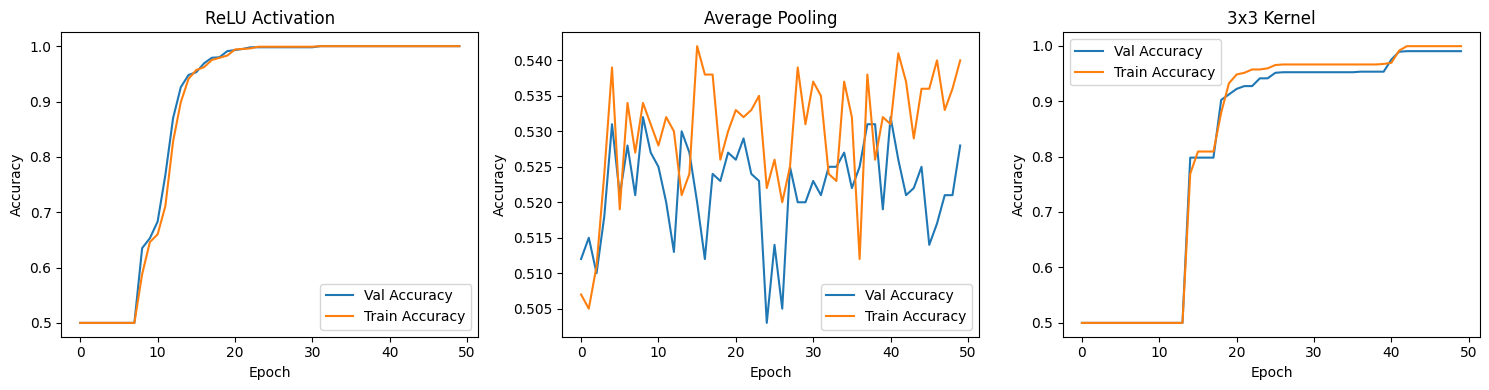

In [16]:
# 1.6 Plot comparisons
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_relu.history['val_accuracy'], label='Val Accuracy')
axes[0].plot(history_relu.history['accuracy'], label='Train Accuracy')
axes[0].set_title('ReLU Activation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history_avg.history['val_accuracy'], label='Val Accuracy')
axes[1].plot(history_avg.history['accuracy'], label='Train Accuracy')
axes[1].set_title('Average Pooling')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

axes[2].plot(history_k3.history['val_accuracy'], label='Val Accuracy')
axes[2].plot(history_k3.history['accuracy'], label='Train Accuracy')
axes[2].set_title('3x3 Kernel')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy'); axes[2].legend()

plt.tight_layout()
plt.show()

**1.6 Comments:**
- **ReLU activation:** Using ReLU instead of linear clips negative activations to zero, which removes information that could help distinguish stripe orientation. This may cause the model to learn more slowly or achieve lower accuracy, since the kernel can no longer use both positive and negative values to differentiate the two classes.
- **Average pooling:** Average pooling takes the mean of all activations rather than the maximum. Since stripes are sparse, the average response is diluted by many zero-valued pixels, making it harder to distinguish the two classes compared to max pooling.
- **Different kernel size (3x3):** A smaller kernel captures less spatial context but can still learn to distinguish vertical from horizontal stripes. It may converge similarly since even a 3x3 kernel can detect directional patterns, though with slightly less information per convolution.

In [20]:
history=model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=50,
                  verbose=1,
                  shuffle=True) 

AttributeError: 'function' object has no attribute 'fit'

In [ ]:
conv_filter=model.get_weights()[0]

# Exercise 2

In [17]:
csvname = 'multiple_sine_waves.csv'
data = np.loadtxt(csvname, delimiter=',')
x = data[:2, :]
y = data[2:, :]
print("x shape:", x.shape, "y shape:", y.shape)

x shape: (2, 100) y shape: (2, 100)


In [ ]:
import autograd.numpy as np
from autograd import value_and_grad

def feature_transforms(x, w):
    a = w[0] + np.dot(x.T, w[1:])
    return np.sin(a).T

def model(x, w):
    f = feature_transforms(x, w[0])
    a = w[1][0] + np.dot(f.T, w[1][1:])
    return a.T

def least_squares(w):
    predictions = model(x, w)
    return np.sum((predictions - y)**2) / y.size


maxits = 2000
alpha = 10**(0)  # alpha = 1.0

np.random.seed(0)
w0 = np.random.randn(3, 2) * 0.1
w1 = np.random.randn(3, 2) * 0.1
w = [w0, w1]

cost_history = []
grad_func = value_and_grad(least_squares)

for k in range(maxits):
    cost, grad = grad_func(w)
    cost_history.append(cost)
    w[0] = w[0] - alpha * grad[0]
    w[1] = w[1] - alpha * grad[1]

print("Final cost:", cost_history[-1])
print("\nOptimal parameters:")
print("w[0] (feature transform weights):\n", w[0])
print("w[1] (linear combination weights):\n", w[1])

Final cost: 1.0208586871654737e-05

Optimal parameters:
w[0] (feature transform weights):
 [[-6.2816556  -6.28068013]
 [ 3.66714267  5.7717769 ]
 [ 8.15320703  5.22499213]]
w[1] (linear combination weights):
 [[ 4.72892745e-04  1.10116728e-03]
 [ 1.00422850e+00 -8.14735803e-03]
 [-7.50119670e-03 -9.95932896e-01]]


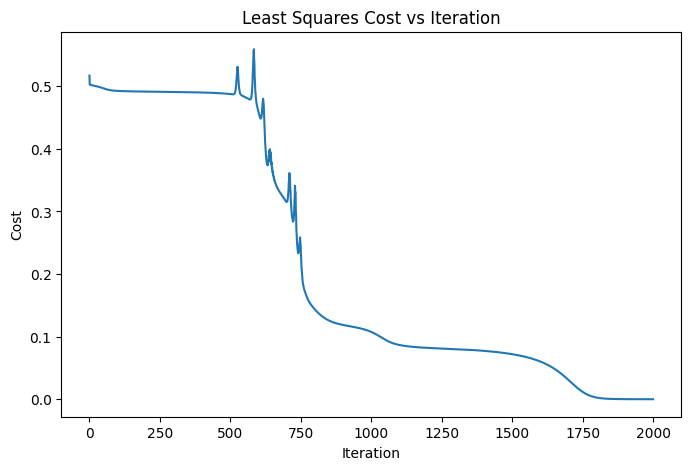

In [ ]:
# Plot cost function vs iteration

plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Least Squares Cost vs Iteration')
plt.show()

# Exercise 3

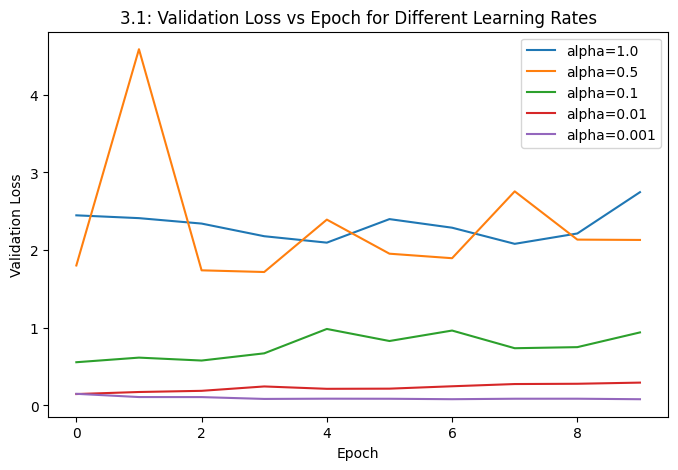

In [22]:
# 3.1 Train with different learning rates and plot val_loss
from tensorflow.keras.datasets import mnist
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

alphas = [1., 0.5, 0.1, 0.01, 0.001]
histories = {}

for alpha in alphas:
    model = keras.Sequential([
        layers.Dense(512, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.RMSprop(alpha),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(train_images, train_labels,
                        epochs=10,
                        batch_size=128,
                        validation_split=0.2,
                        verbose=0)
    histories[alpha] = history

plt.figure(figsize=(8, 5))
for alpha in alphas:
    plt.plot(histories[alpha].history['val_loss'], label=f'alpha={alpha}')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('3.1: Validation Loss vs Epoch for Different Learning Rates')
plt.legend()
plt.show()

**3.1 Comments:** As we decrease the learning rate, the validation loss curve becomes smoother and converges more reliably. For alpha=1.0, the learning rate is far too large — the optimizer overshoots the minimum, causing the loss to be erratic and high (essentially the model fails to learn properly). For alpha=0.5 and 0.1, the loss decreases but may still be unstable. For alpha=0.01 and 0.001, the loss decreases steadily — alpha=0.001 converges the most smoothly but more slowly. This demonstrates the classic tradeoff: too large a learning rate causes divergence/instability, while too small a learning rate leads to slow convergence.

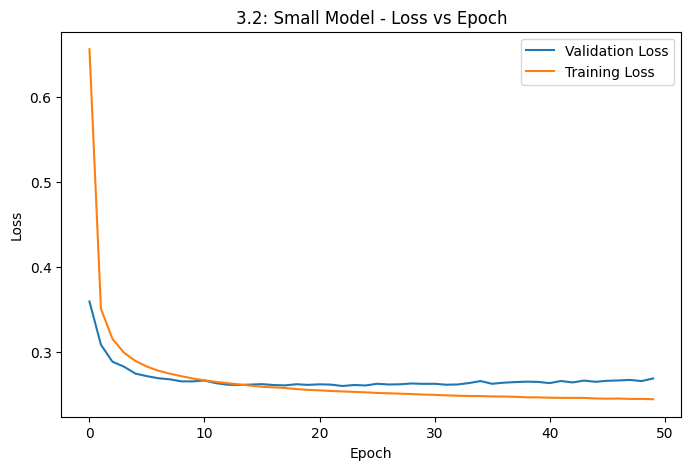

In [23]:
# 3.2 Small model (logistic regression only)
model = keras.Sequential([layers.Dense(10, activation='softmax')])
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history_small_model = model.fit(
    train_images, train_labels,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    verbose=0)

plt.figure(figsize=(8, 5))
plt.plot(history_small_model.history['val_loss'], label='Validation Loss')
plt.plot(history_small_model.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('3.2: Small Model - Loss vs Epoch')
plt.legend()
plt.show()

**3.2 Comments:** For this small model (just logistic regression with no hidden layers), there is no clear minimum in the validation loss — both training and validation loss decrease together and plateau. There is no significant overfitting because the model has very limited capacity (only 7,850 parameters). It simply cannot memorize the training data, so the training and validation losses remain close throughout. The model is underfitting rather than overfitting.

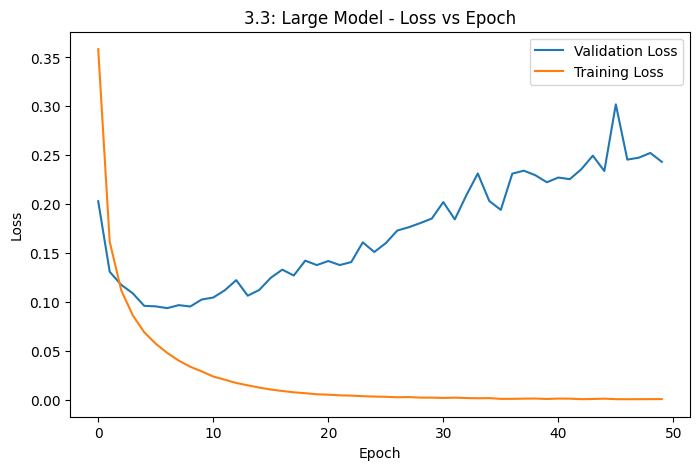

In [24]:
# 3.3 Larger model with hidden layers
model = keras.Sequential([
    layers.Dense(96, activation='relu'),
    layers.Dense(96, activation='relu'),
    layers.Dense(10, activation='softmax'),
])
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history_large_model = model.fit(
    train_images, train_labels,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    verbose=0)

plt.figure(figsize=(8, 5))
plt.plot(history_large_model.history['val_loss'], label='Validation Loss')
plt.plot(history_large_model.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('3.3: Large Model - Loss vs Epoch')
plt.legend()
plt.show()

**3.3 Comments:** For the larger model with two hidden layers (96 units each), there is a clear minimum in the validation loss followed by a well-defined region of overfitting. The training loss continues to decrease throughout training, but the validation loss reaches a minimum around epoch 5-10 and then starts increasing. This divergence between training and validation loss is classic overfitting — the model has enough capacity to memorize the training data, causing it to generalize poorly to unseen data. Compared to the small model in 3.2, the increased complexity allows better performance initially but makes the model prone to overfitting with continued training.

# Exercise 4

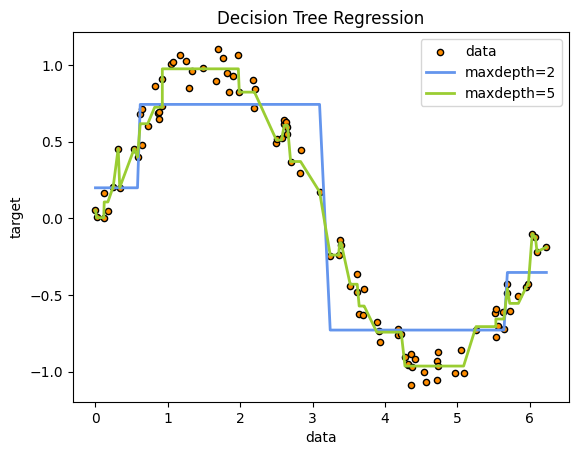

In [27]:
# Import the necessary modules and libraries
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Create a random dataset
rng = np.random.RandomState(1)
X = np.sort(6.3 * rng.rand(100, 1), axis=0)
y = np.sin(X).ravel()
y += 0.3 * (0.5 - rng.rand(len(X)))
# Fit regression model
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_1.fit(X, y)
regr_2.fit(X, y)

# Predict
y_1 = regr_1.predict(X)
y_2 = regr_2.predict(X)

# Plot the results
plt.figure()
plt.scatter(X, y, s=20, edgecolor="black",
            c="darkorange", label="data")
plt.plot(X, y_1, color="cornflowerblue",
         label="maxdepth=2", linewidth=2)
plt.plot(X, y_2, color="yellowgreen", label="maxdepth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

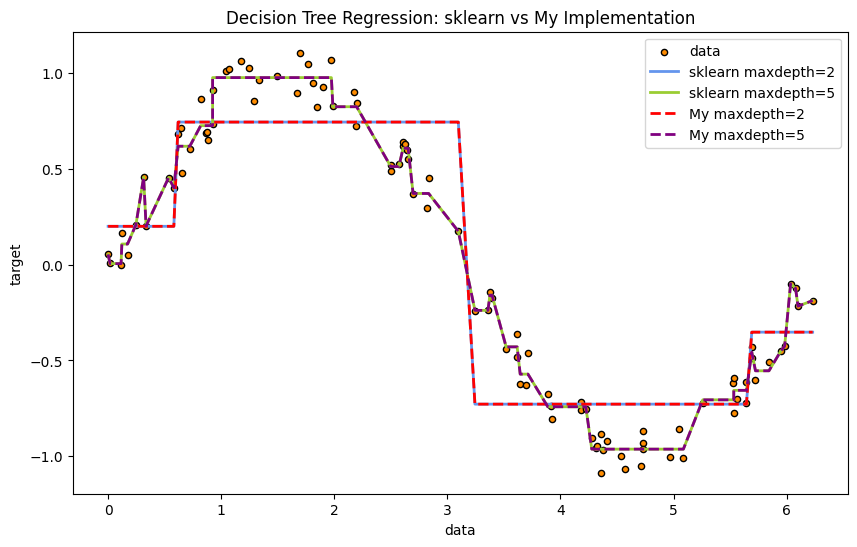

In [26]:
def My_TreeRegressor(y, il, ir, max_depth, level=0):
    global yreg
    if level == 0:
        yreg = np.zeros(len(y))
    
    # Base case: single point or empty interval
    if ir - il <= 1:
        yreg[il:ir] = np.mean(y[il:ir])
        return
    
    # Base case: reached max depth, assign mean of interval
    if level >= max_depth:
        yreg[il:ir] = np.mean(y[il:ir])
        return
    
    # Find optimal split point using least squares cost
    best_cost = np.inf
    best_s = il
    
    for s in range(il + 1, ir):
        left_mean = np.mean(y[il:s])
        right_mean = np.mean(y[s:ir])
        cost = np.sum((y[il:s] - left_mean)**2) + np.sum((y[s:ir] - right_mean)**2)
        if cost < best_cost:
            best_cost = cost
            best_s = s
    
    # Recurse on left and right intervals
    My_TreeRegressor(y, il, best_s, max_depth, level + 1)
    My_TreeRegressor(y, best_s, ir, max_depth, level + 1)

# Test with max_depth=2
My_TreeRegressor(y, 0, len(y), max_depth=2)
my_y1 = yreg.copy()

# Test with max_depth=5
My_TreeRegressor(y, 0, len(y), max_depth=5)
my_y2 = yreg.copy()

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X, y_1, color="cornflowerblue", label="sklearn maxdepth=2", linewidth=2)
plt.plot(X, y_2, color="yellowgreen", label="sklearn maxdepth=5", linewidth=2)
plt.plot(X, my_y1, color="red", label="My maxdepth=2", linewidth=2, linestyle='--')
plt.plot(X, my_y2, color="purple", label="My maxdepth=5", linewidth=2, linestyle='--')
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression: sklearn vs My Implementation")
plt.legend()
plt.show()

**Exercise 5 Comments:** Yes, the results agree. The custom tree regressor (dashed lines) matches the sklearn DecisionTreeRegressor (solid lines) for both max_depth=2 and max_depth=5. Both implementations find the same optimal split points by minimizing the least squares cost at each node, and assign the mean of the y-values in each leaf region. The max_depth=2 tree provides a coarser fit with fewer regions, while max_depth=5 captures more detail in the data but risks overfitting to noise.